# NB 15 — Prediction prototype (PCA)

End-to-end predict path on a single anomaly slice from `test_intern_raw.npy`.
Goal: prove a clean `predict_slice(df_raw, threshold)` contract and the four
prediction-phase plots in `viz.py`, so the team can wire this into the API
and the frontend.

This notebook is a prototype — it does **not** modify `predictor_pca.py`.
The function at the bottom of the notebook is the proposed v2 contract,
built on top of `score_report` from `scoring.py`.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sentinel.params import PCA_THRESHOLD, WINDOW_SIZE
from sentinel.ml_logic.data import MODELS_DIR, PROCESSED_DIR
from sentinel.ml_logic.scoring import score_report
from sentinel.ml_logic.metrics import event_f05, row_precision_recall
from sentinel.ml_logic.viz import (
    plot_score_distribution,
    plot_score_timeline,
    plot_event_zoom_with_score,
    plot_confusion_and_channel_errors,
)

sns.set_theme(style="whitegrid")
print("threshold:", PCA_THRESHOLD, " window:", WINDOW_SIZE)

threshold: 0.060404  window: 100


## 2. Load artefacts

Everything the predictor needs lives in `models/` and `data/processed/`:
the fitted PCA, the RobustScaler, and the list of 58 target channels.

In [2]:
with open(MODELS_DIR / "pca.pkl", "rb") as f:
    pca = pickle.load(f)
with open(MODELS_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(PROCESSED_DIR / "preprocessing_config.json") as f:
    features = json.load(f)["target_channels"]

print("PCA components:", pca.n_components_)
print("scaler fitted on", scaler.n_features_in_, "features")
print("features:", len(features), "channels")

PCA components: 38
scaler fitted on 58 features
features: 58 channels


## 3. Pick a slice

We load the held-out `test_intern_raw.npy` (raw, **unscaled**) together
with its binary labels, then cut a slice around an anomaly event with
clean background: event `98,664–98,688` (25 rows). Peak row-score ~3.1
vs. threshold ~0.06, and nominal windows in the ±2 000-row neighbourhood
stay at ~0.04 — so we see a clear true-positive spike against a flat
baseline, without the model flagging its surroundings.

In [3]:
X_raw_all = np.load(PROCESSED_DIR / "test_intern_raw.npy", mmap_mode="r")
y_all     = np.load(PROCESSED_DIR / "y_test_intern.npy")
print("test_intern:", X_raw_all.shape, " anomalies:", int(y_all.sum()))

EV_START = 98_664
EV_END   = 98_688
CONTEXT  = 2_000

lo = max(0, EV_START - CONTEXT)
hi = min(len(X_raw_all), EV_END + CONTEXT + 1)

df_slice = pd.DataFrame(
    np.asarray(X_raw_all[lo:hi]),
    columns=features,
    index=np.arange(lo, hi),
)
df_slice["is_anomaly"] = y_all[lo:hi].astype(np.int8)
print("slice rows:", len(df_slice), " anomalies:", int(df_slice['is_anomaly'].sum()))

test_intern: (2186220, 58)  anomalies: 214961
slice rows: 4025  anomalies: 25


## 4. Prototype `predict_slice`

Proposed contract for `predictor_pca.py v2`. It's a thin wrapper around
`score_report`: one reconstruction pass, and the returned dict already
carries everything the four prediction-phase plots need — no hand-rolled
PCA loop in the notebook.

The function is deliberately pure: no file I/O, no plotting, no globals.

In [4]:
def predict_slice(df_raw: pd.DataFrame, threshold: float = PCA_THRESHOLD) -> dict:
    """
    Run the PCA anomaly detector on a slice of raw sensor data.

    Parameters
    ----------
    df_raw    : DataFrame with at least the 58 target channels as columns.
                A row-level ``is_anomaly`` column is allowed but ignored.
    threshold : decision threshold applied to ``row_scores``.

    Returns
    -------
    dict with keys
        labels             : int8  (n_rows,)      0 = nominal, 1 = anomaly
        row_scores         : float32 (n_rows,)    per-row anomaly score
        window_scores      : float32 (n_win,)     per-window anomaly score
        per_channel_mse    : float32 (58,)        mean MSE per channel
        window_channel_mse : float32 (n_win, 58)  per-window per-channel MSE
        threshold          : float                threshold actually used
        features           : list[str]            channel order used by PCA
    """
    X        = df_raw[features].values.astype(np.float32)
    X_scaled = scaler.transform(X).astype(np.float32)

    rep    = score_report(pca, X_scaled, win=WINDOW_SIZE)
    labels = (rep["row_scores"] > threshold).astype(np.int8)

    return {
        "labels"            : labels,
        "row_scores"        : rep["row_scores"],
        "window_scores"     : rep["window_scores"],
        "per_channel_mse"   : rep["per_channel_mse"],
        "window_channel_mse": rep["window_channel_mse"],
        "threshold"         : float(threshold),
        "features"          : features,
    }

## 5. Run prediction + sanity assertions

In [5]:
out = predict_slice(df_slice)

expected_keys = {
    "labels", "row_scores", "window_scores",
    "per_channel_mse", "window_channel_mse",
    "threshold", "features",
}
assert set(out) == expected_keys
assert out["labels"].shape           == (len(df_slice),)
assert out["row_scores"].shape       == (len(df_slice),)
assert out["per_channel_mse"].shape  == (len(features),)
assert out["window_channel_mse"].shape[1] == len(features)
assert out["labels"].dtype == np.int8
assert set(np.unique(out["labels"])).issubset({0, 1})

print("rows           :", len(df_slice))
print("true anom      :", int(df_slice['is_anomaly'].sum()))
print("predicted      :", int(out['labels'].sum()))
print("row-score range:", float(out['row_scores'].min()), '–', float(out['row_scores'].max()))
print("threshold      :", out['threshold'])
assert out["labels"].sum() > 0, "Threshold too high for this slice — pick a stronger event."

rows           : 4025
true anom      : 25
predicted      : 100
row-score range: 0.028554098680615425 – 3.076554775238037
threshold      : 0.060404


## 6. Metrics on the slice

Event-wise F0.5 is the primary tuning metric; the row-level numbers feed
the frontend headline tiles.

In [6]:
y_true = df_slice["is_anomaly"].values
y_pred = out["labels"]

ef05 = event_f05(y_true, y_pred)
rpr  = row_precision_recall(y_true, y_pred)

print("event F0.5  :", ef05['f_score'],
      f"  (tp={ef05['tp_events']}, fn={ef05['fn_events']}, fp_pred={ef05['fp_pred_events']})")
print("row   F1    :", rpr['f1'],
      f"  (precision={rpr['precision']}, recall={rpr['recall']})")

event F0.5  : 1.0   (tp=1, fn=0, fp_pred=0)
row   F1    : 0.4   (precision=0.25, recall=1.0)


## 7. Visuals

Four plots, one per cell — same set the API will expose to the frontend.

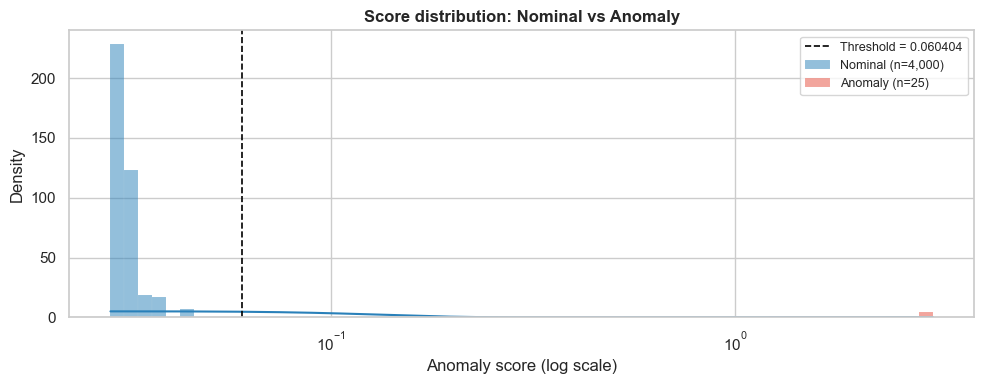

In [7]:
plot_score_distribution(out["row_scores"], y_true, out["threshold"]);

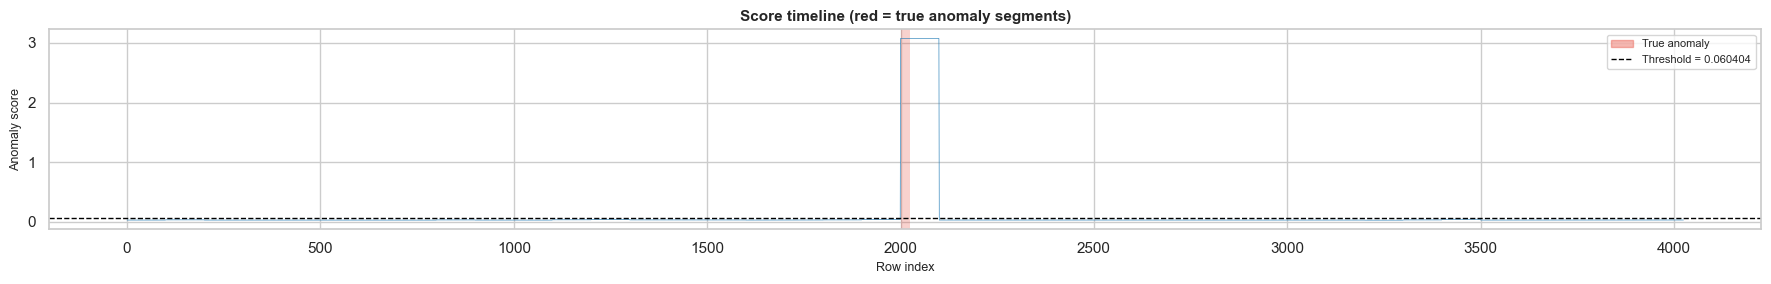

In [8]:
plot_score_timeline(out["row_scores"], y_true, out["threshold"]);

top channels (by anomaly-window MSE): ['channel_43', 'channel_45', 'channel_41', 'channel_46']


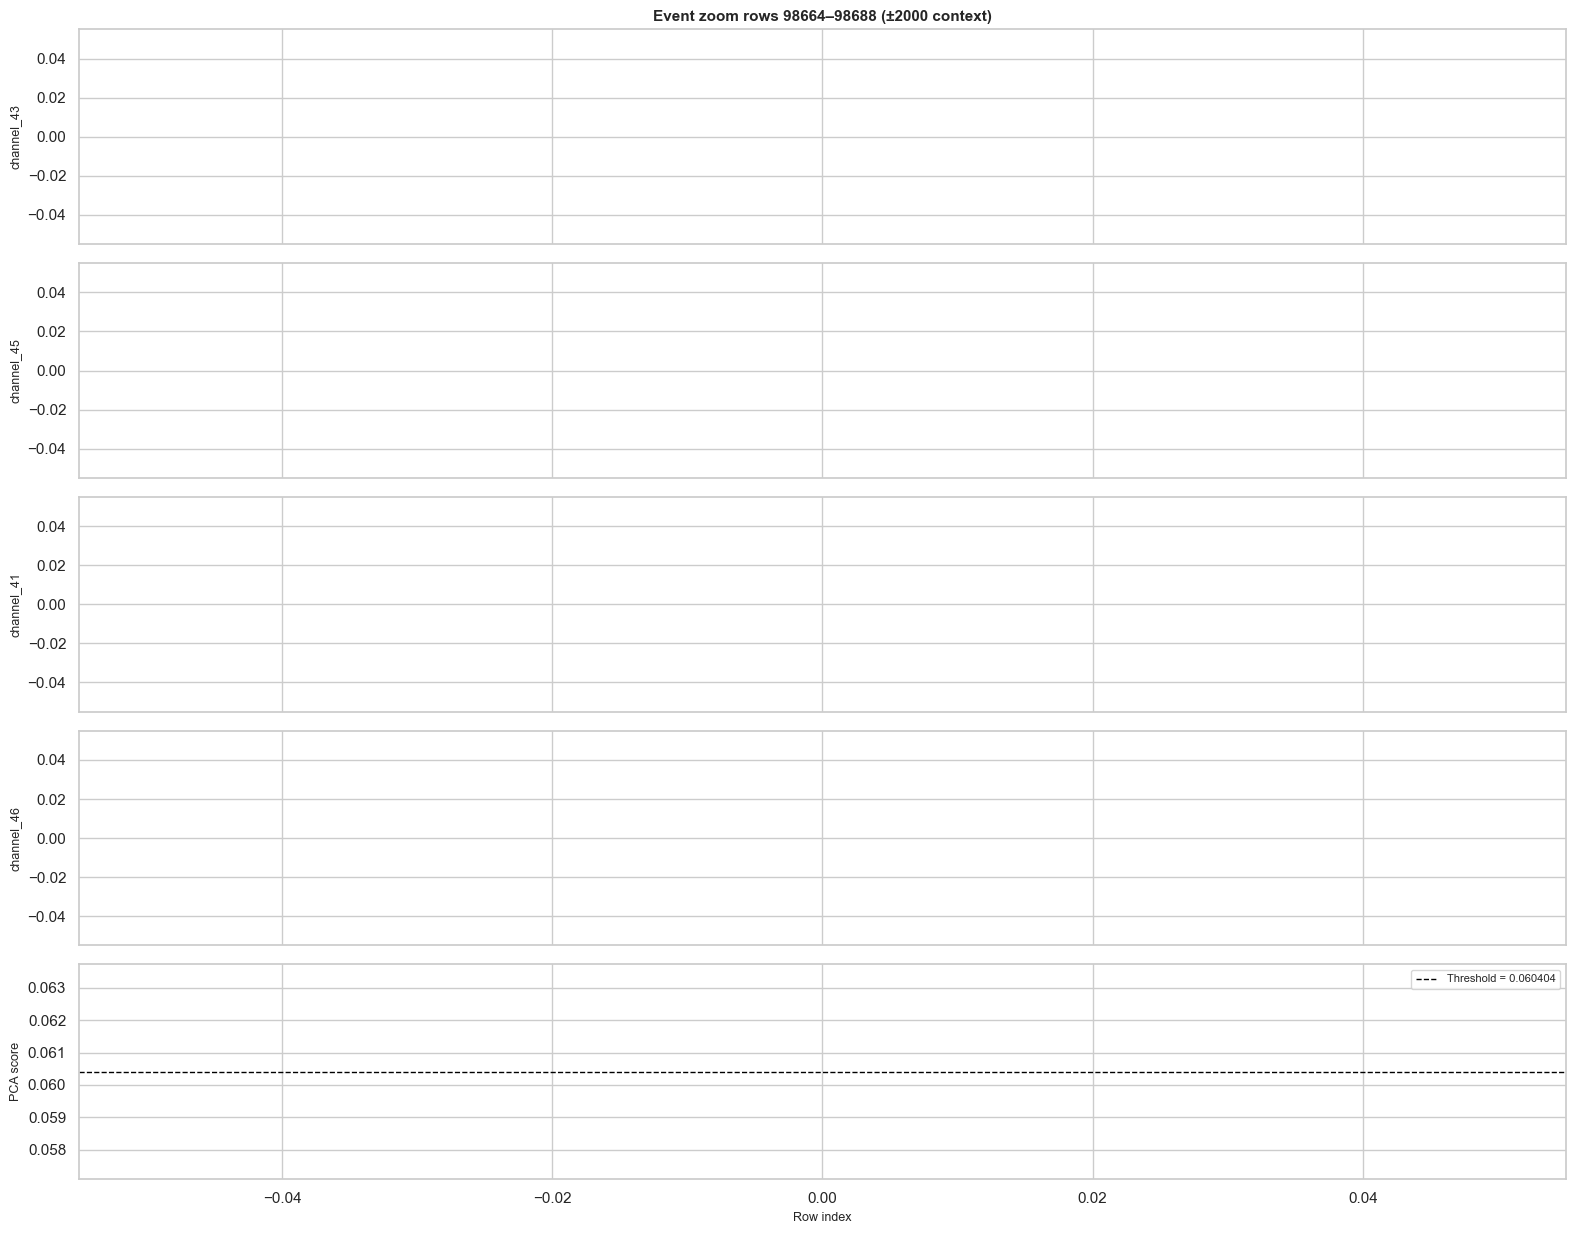

In [9]:
# Rank channels by the MSE inside the anomaly windows, not the slice-wide
# average — otherwise a 1 % anomaly in a 4k-row slice is drowned out by
# nominal noise. window_channel_mse from score_report makes this trivial.
win_scores    = out["window_scores"]
anom_win_mask = win_scores > out["threshold"]
if anom_win_mask.any():
    per_ch_anom = out["window_channel_mse"][anom_win_mask].mean(axis=0)
else:
    per_ch_anom = out["per_channel_mse"]

top_channels = [features[i] for i in np.argsort(per_ch_anom)[::-1][:4]]
print("top channels (by anomaly-window MSE):", top_channels)

plot_event_zoom_with_score(
    df_raw=df_slice,
    scores=out["row_scores"],
    seg_start=EV_START,
    seg_end=EV_END,
    channels=top_channels,
    threshold=out["threshold"],
    context=CONTEXT,
);

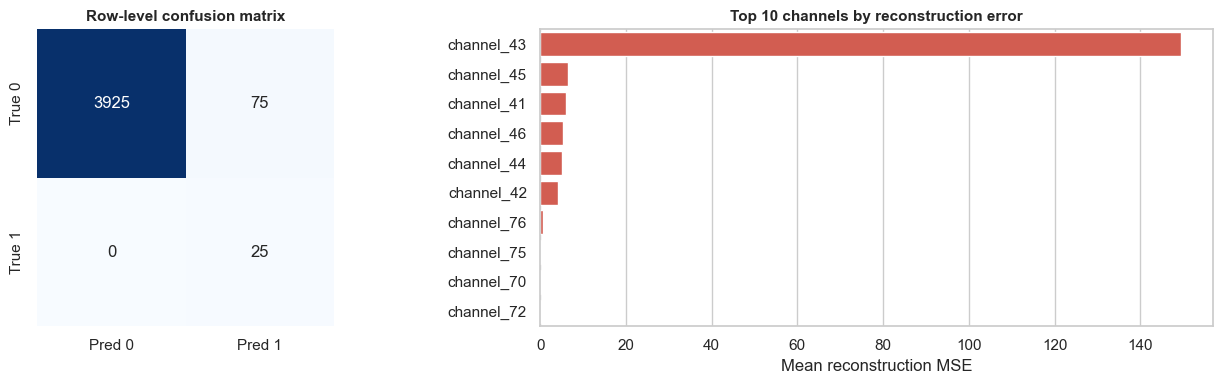

In [10]:
# The confusion matrix shows row-level predictions; the bar chart ranks
# channels by anomaly-window MSE (same rule as the zoom plot above) so the
# two diagnostics agree on 'which channels drove the detection'.
plot_confusion_and_channel_errors(
    y_true=y_true,
    y_pred=y_pred,
    per_channel_mse=per_ch_anom,
    channel_names=features,
    top_k=10,
);

## 8. Contract for `predictor_pca.py` v2

The existing `predict(X_raw, threshold, return_scores=False)` covers the
Kaggle-submission path (one array of labels over the full test set). The
frontend needs more than that on a per-slice basis — scores, per-channel
MSE, and the per-window per-channel matrix for "which channels drove
this?" diagnostics.

Proposed next step: promote `predict_slice` (above) into
`src/sentinel/ml_logic/predictor_pca.py` with this contract:

```python
def predict_slice(df_raw: pd.DataFrame, threshold: float = PCA_THRESHOLD) -> dict:
    '''Returns {labels, row_scores, window_scores, per_channel_mse,
                window_channel_mse, threshold, features}.'''
```

Everything else (lazy model loading, the thin `predict` wrapper) stays
as-is. The four `viz.py` plots then consume entries from the dict
directly — no further glue code needed.